In [ ]:
import pandas as pd

LOG_FILES = ['LOG1.log', 'LOG2.log']

def load_log(path):
    df = pd.read_csv(path, sep=r'\]\s*', engine='python', header=None)
    col_names = ['timestamp'] + df.iloc[0, 1].split(',')
    df = df.iloc[1:].reset_index(drop=True)
    df = pd.concat([df[0].str.lstrip('['), df[1].str.split(',', expand=True)], axis=1)
    df.columns = col_names
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

df = pd.concat([load_log(f) for f in LOG_FILES], ignore_index=True)
numeric_cols = df.columns.difference(['timestamp'])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [18]:
pb_cols = ['PB1', 'PB2', 'PB3', 'PB4']
df['PB_avg'] = df[pb_cols].mean(axis=1)
df['TFT'] = df[['STFT','LTFT']].sum(axis=1)
display(df)

,timestamp,RPM,MAP,PB1,PB2,PB3,PB4,STFT,LTFT,FuelCL,lambda_cmd,O2_lambda,O2_voltage,PB_avg,TFT
0,2026-04-09 20:52:08.258,975,0.45,1.88,1.90,1.88,2.09,-7.81,0.00,1,0.9902,0.0,0.0,1.9375,-7.81
1,2026-04-09 20:52:08.295,977,0.46,1.88,1.88,1.88,2.09,-7.81,0.00,1,0.9902,0.0,0.0,1.9325,-7.81
2,2026-04-09 20:52:08.350,977,0.46,1.87,1.88,1.82,2.09,-7.81,0.00,1,0.9902,0.0,0.0,1.9150,-7.81
3,2026-04-09 20:52:08.386,977,0.45,1.87,1.88,1.82,2.02,-7.81,0.00,1,0.9902,0.0,0.0,1.8975,-7.81
4,2026-04-09 20:52:08.444,977,0.46,1.83,1.84,1.82,2.02,-7.81,0.00,1,0.9902,0.0,0.0,1.8775,-7.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93062,2026-04-09 22:21:40.510,712,0.35,1.36,1.36,1.43,1.53,9.38,17.19,1,0.9902,0.0,0.0,1.4200,26.57
93063,2026-04-09 22:21:40.542,712,0.35,1.36,1.36,1.42,1.53,9.38,17.19,1,0.9902,0.0,0.0,1.4175,26.57
93064,2026-04-09 22:21:40.620,712,0.35,1.36,1.36,1.42,1.59,9.38,17.19,1,0.9902,0.0,0.0,1.4325,26.57
93065,2026-04-09 22:21:40.649,713,0.35,1.36,1.48,1.42,1.59,9.38,17.19,1,0.9902,0.0,0.0,1.4625,26.57


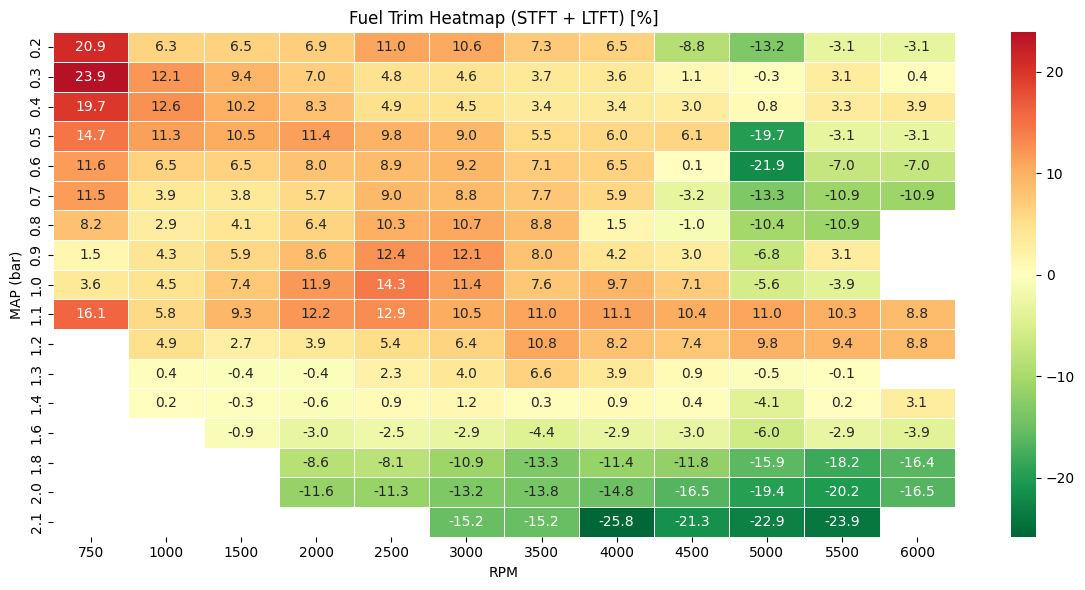

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define bin breakpoints for RPM and MAP
rpms = [750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000]
maps = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.6, 1.8, 2.0, 2.1]

ran = 0
mode = 0  # 0 = hard boundaries, 1 = midpoint boundaries

df['ft'] = df['STFT'] + df['LTFT']

ft = []

for i_map in range(len(maps)):
    temp_ft = []
    for i_rpm in range(len(rpms)):
        # RPM boundaries
        if i_rpm <= ran:
            min_rpm = 0
        else:
            min_rpm = (rpms[i_rpm - 1 - ran] + rpms[i_rpm]) / 2 if mode else rpms[i_rpm - 1 - ran]

        if i_rpm >= len(rpms) - 1 - ran:
            max_rpm = 9999
        else:
            max_rpm = (rpms[i_rpm + 1 + ran] + rpms[i_rpm]) / 2 if mode else rpms[i_rpm + 1 + ran]

        # MAP boundaries
        if i_map <= ran:
            min_map = 0
        else:
            min_map = (maps[i_map - 1 - ran] + maps[i_map]) / 2 if mode else maps[i_map - 1 - ran]

        if i_map >= len(maps) - 1 - ran:
            max_map = 9999
        else:
            max_map = (maps[i_map + 1 + ran] + maps[i_map]) / 2 if mode else maps[i_map + 1 + ran]

        df_filtered = df[
            (df['RPM'] >= min_rpm) & (df['RPM'] < max_rpm) &
            (df['MAP'] >= min_map) & (df['MAP'] < max_map)
        ]
        temp_ft.append(round(df_filtered['ft'].mean(), 1))
    ft.append(temp_ft)

ft_df = pd.DataFrame(ft, columns=rpms, index=maps)

plt.figure(figsize=(12, 6))
sns.heatmap(
    ft_df,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',     # red = rich/negative trim, green = lean/positive
    center=0,            # center colormap at 0% trim
    linewidths=0.5,
)
plt.title('Fuel Trim Heatmap (STFT + LTFT) [%]')
plt.xlabel('RPM')
plt.ylabel('MAP (bar)')
plt.tight_layout()
plt.show()

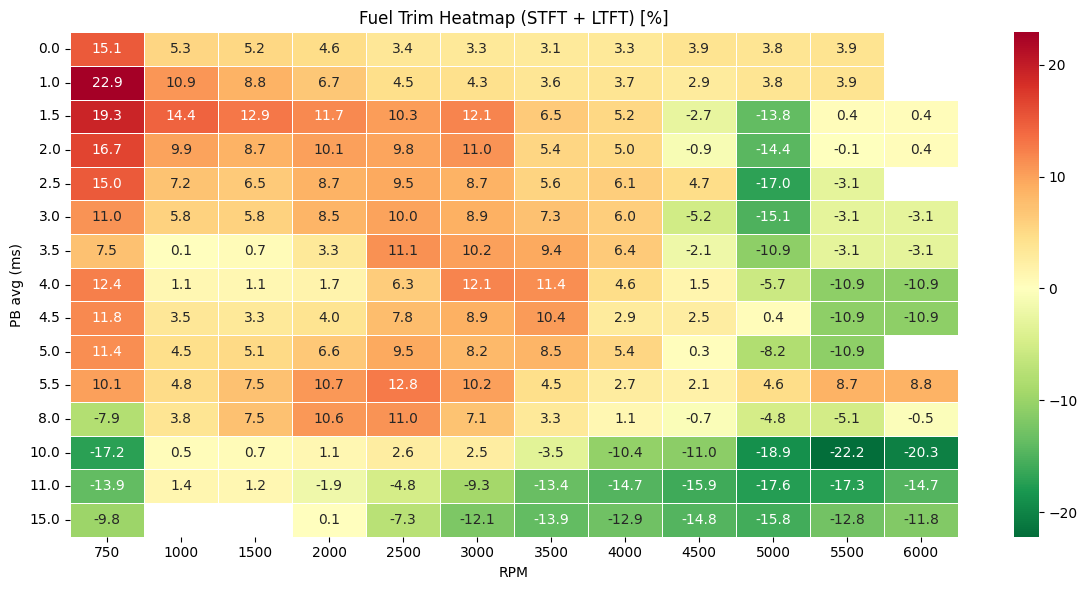

In [27]:
rpms = [750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000]
pb_avgs = [0, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 8, 10, 11, 15]

ran = 0
mode = 0

df['ft'] = df['STFT'] + df['LTFT']

ft = []

for i_pb in range(len(pb_avgs)):
    temp_ft = []
    for i_rpm in range(len(rpms)):
        # RPM boundaries
        if i_rpm <= ran:
            min_rpm = 0
        else:
            min_rpm = (rpms[i_rpm - 1 - ran] + rpms[i_rpm]) / 2 if mode else rpms[i_rpm - 1 - ran]

        if i_rpm >= len(rpms) - 1 - ran:
            max_rpm = 9999
        else:
            max_rpm = (rpms[i_rpm + 1 + ran] + rpms[i_rpm]) / 2 if mode else rpms[i_rpm + 1 + ran]

        # PB_avg boundaries
        if i_pb <= ran:
            min_pb = 0
        else:
            min_pb = (pb_avgs[i_pb - 1 - ran] + pb_avgs[i_pb]) / 2 if mode else pb_avgs[i_pb - 1 - ran]

        if i_pb >= len(pb_avgs) - 1 - ran:
            max_pb = 9999
        else:
            max_pb = (pb_avgs[i_pb + 1 + ran] + pb_avgs[i_pb]) / 2 if mode else pb_avgs[i_pb + 1 + ran]

        df_filtered = df[
            (df['RPM'] >= min_rpm) & (df['RPM'] < max_rpm) &
            (df['PB_avg'] >= min_pb) & (df['PB_avg'] < max_pb)
        ]
        temp_ft.append(round(df_filtered['ft'].mean(), 1))
    ft.append(temp_ft)

ft_df = pd.DataFrame(ft, columns=rpms, index=pb_avgs)

plt.figure(figsize=(12, 6))
sns.heatmap(
    ft_df,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5,
)
plt.title('Fuel Trim Heatmap (STFT + LTFT) [%]')
plt.xlabel('RPM')
plt.ylabel('PB avg (ms)')
plt.tight_layout()
plt.show()